<a href="https://colab.research.google.com/github/PFesta-unipi/PFesta-unipi.github.io/blob/main/PietroFesta_integrazione.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**

## **Esercitazione 7: Calcolo numerico di integrali**

Supponiamo di avere una funzione reale continua di variabile reale

$$f:[a,b]\longrightarrow\mathbb{R}.$$

Ci poniamo il problema di approssimare numericamente l'integrale

$$
\int_a^b f(x)dx.
$$

In questa esercitazione vedremo alcuni metodi classici concepiti per risolvere il problema. L'idea generale alla base di questi metodi consiste nel suddividere l'intervallo $[a,b]$ in tanti piccoli sottointervalli e, su ciascun sottointervallo, approssimare $f$ per mezzo di una funzione più semplice (per esempio lineare o polinomiale). Osserviamo che, per applicare questi metodi, non è necessario conoscere esplicitamente l'espressione della funzione $f$; è sufficiente saperla valutare in certi punti dell'intervallo $[a,b]$.  

---
# Setup iniziale
Carichiamo le librerie necessarie (in particolare `QuadGK`, che contiene funzionalità Julia per approssimare numericamente gli integrali).

In [1]:
import Pkg; Pkg.add( "QuadGK" )
import Pkg; Pkg.add( "QuadGK" )


using Plots
using QuadGK

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [1fd47b50] + QuadGK v2.11.3
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Nota: se le istruzioni precedenti danno errore, potrebbe essere necessario caricare la libreria con le istruzioni
```julia
import Pkg; Pkg.add( "QuadGK" )
```

---
# 1. Metodo dei trapezi


Suddividiamo l'intervallo $[a,b]$ in $N$ sottointervalli $[t_i,t_{i+1}]$, ciascuno di ampiezza $h=\frac{b-a}{N}$. Avremo quindi

$$
t_i=a + i\,h,\qquad i=0,\ldots , N.
$$

In ciascun sottointervallo l'integrale viene approssimato come l'area del trapezio di altezza $h$ le cui basi sono il segmento di estremi $(t_i,0)$, $(t_i,f(t_i))$ e il segmento di estremi $(t_{i+1},0)$, $(t_{i+1},f(t_{i+1}))$. Le aree dei trapezi così determinati vengono sommate per approssimare l'integrale cercato. La formula che ne deriva è

$$
\int_a^b f(x)dx\approx h\left(\frac{f(a)+f(b)}{2}+
\sum_{j=1}^{N-1}f(a+jh)\right).
$$  

Un esempio con $f(x)=0.5\,x^2$, $a=1$, $b=4$ e $N=3$  è illustrato nella figura qui sotto.

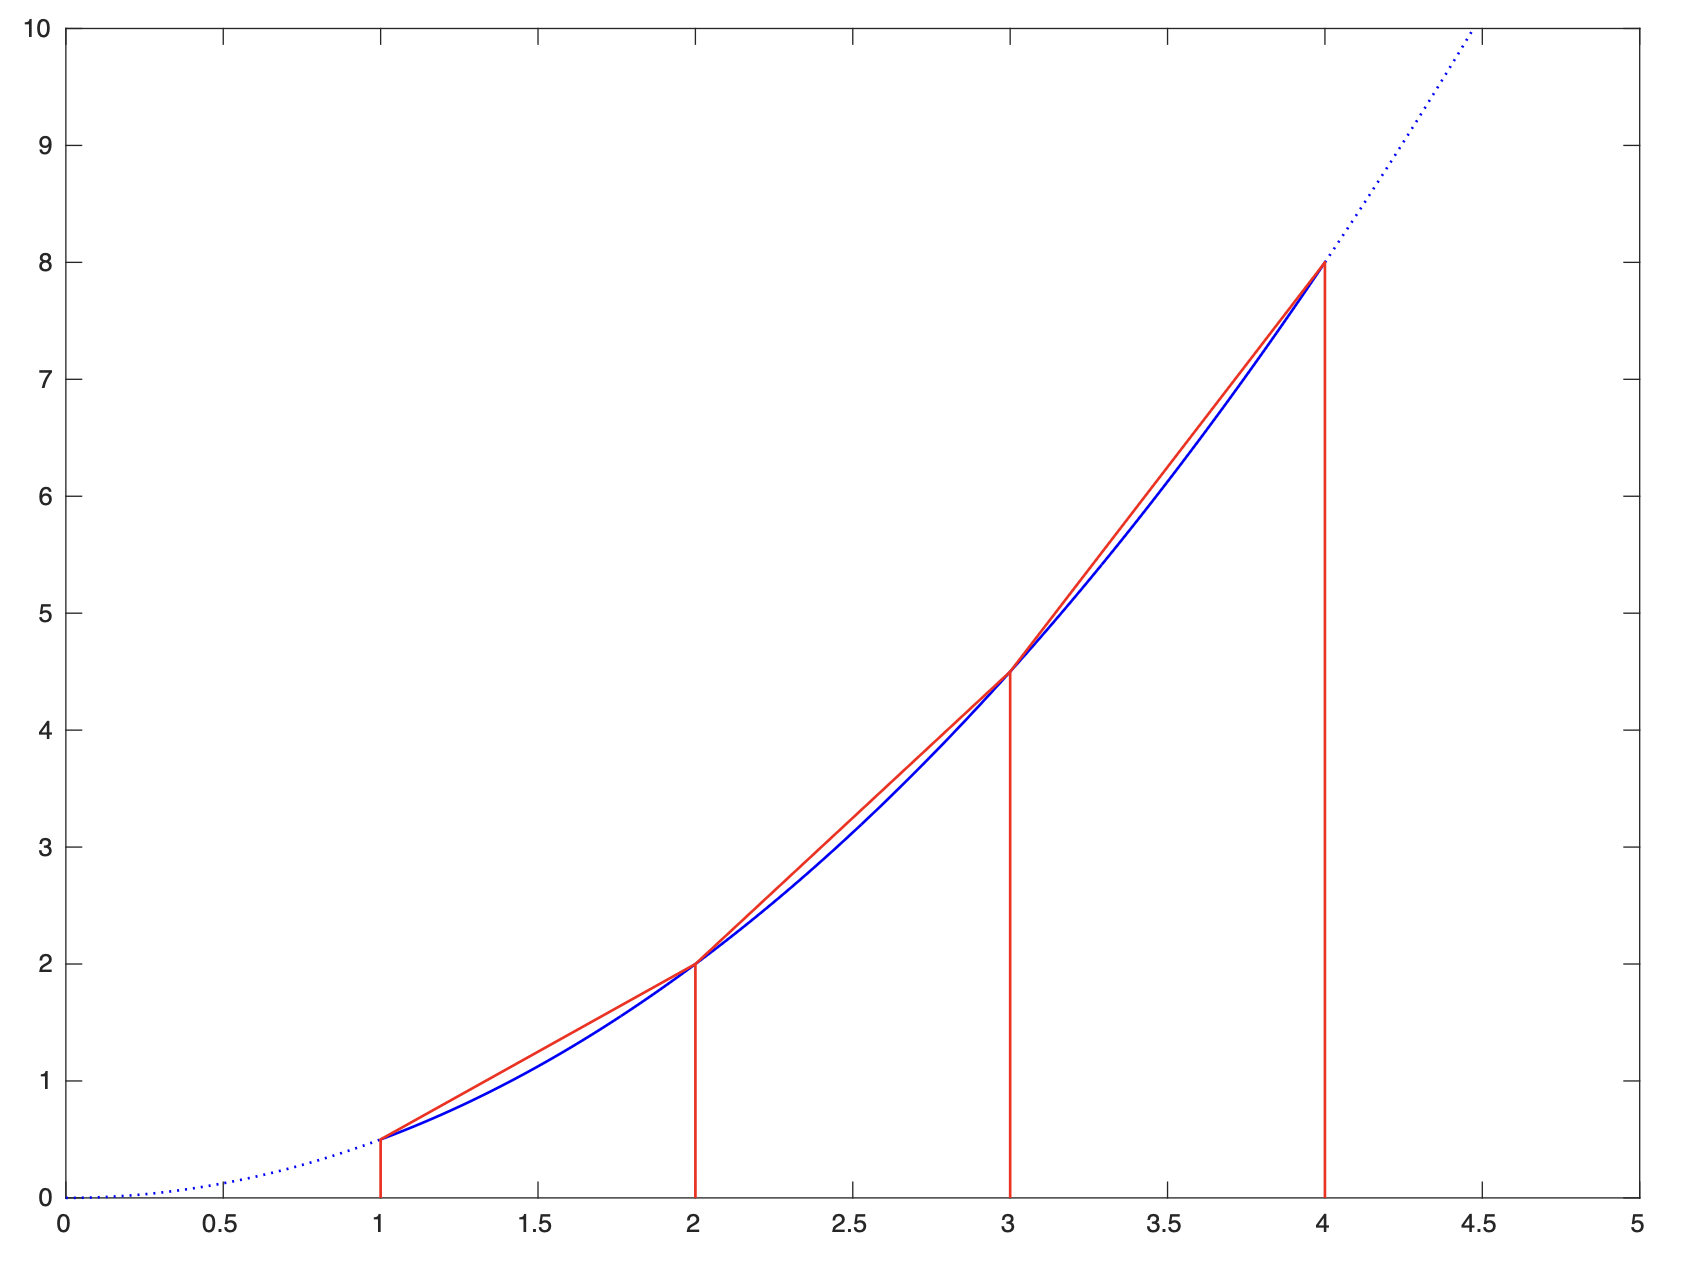


**Esercizio 1**. Scrivere una function `trapezi(f,a,b,N)` che prenda in ingresso

* una funzione `f`,
* gli estremi di integrazione `a` e `b`,
* il numero `N` di sottointervalli da usare,

e restituisca l'approssimazione `S` dell'integrale di `f` tra `a` e `b` ottenuta con il metodo dei trapezi.

In [2]:
function trapezi(f,a,b,N)
  h=(b-a)/N
  s=(f(a)-f(b))/2
  for i in 1:N-1
    s=s+f(a+i*h)
  end
  s=h*s
  return s
end

trapezi (generic function with 1 method)

Verificate la correttezza dell'implementazione su un integrale noto, per esempio

$$
\int_0^1 e^xdx,
$$

che vale $e-1$. Sullo stesso esempio potete controllare che, come è ragionevole aspettarsi, l'accuratezza dell'approssimazione ottenuta migliora al crescere di $N$.

In [5]:
f(x)=exp(x)
N=1000
trapezi(f, 0.0, 1.0, N)

1.715563689820737

**Esercizio 2**. Elaborando di più sul test appena fatto, si calcoli e rappresenti graficamente l'errore di approssimazione del metodo dei trapezi per $N$ crescente.  

Se la funzione da integrare è sufficientemente regolare, la teoria afferma che l'errore decresce proporzionalmente a $h^2$ (o, il che è equivalente, $1/N^2$). Verificate sperimentalmente questa proprietà. Starà a voi scegliere dei valori di $N$ opportuni.

(Suggerimento: potete rappresentare i valori di $N$ e gli errori in scala log-log, applicare un fit lineare e constatare che la pendenza della retta è vicina a $2$).

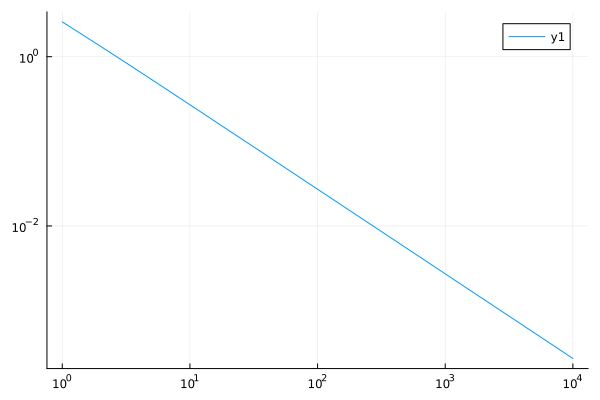

In [6]:
t=range(1, 10000, length=10000)
v=[]
for i in 1:10000
  app=trapezi(f, 0.0, 1.0, i)
  push!(v,abs(app-exp(1)+1))
end
plot(t, v, xscale=:log10, yscale=:log10)

---
# 2. Metodo di Simpson


Come il metodo dei trapezi, anche il metodo di Simpson parte da una suddivisione di $[a,b]$ in sottointervalli. In questo caso, però, la funzione da integrare è approssimata localmente da un polinomio quadratico, anzichè da una funzione lineare. La formula di approssimazione associata al cosiddetto *metodo di Simpson composito* è:

$$
\int_a^b f(x)dx\approx\frac{h}{3}\left(f(a)+f(b)+2\sum_{j=1}^{N/2-1}f(a+2jh)+4\sum_{j=1}^{N/2}f(a+(2j-1)h)\right),
$$

dove si suppone che $N$ sia pari e, come al solito, si definisce $h=\frac{b-a}{N}$.

**Esercizio 3**. Come nell'Esercizio 1, scrivere una function `simpson(f,a,b,N)` che approssimi l'integrale di `f` tra `a` e `b` usando il metodo di Simpson con suddivisione in `N` intervalli, dove si assume che `N` sia pari.

In [7]:
function simp(f,a,b,M)
  N=2*M
  h=(b-a)/N
  s=f(a)+f(b)
  for i in 1:M-1
    s=s+2*f(a+2*i*h)
  end
  for i in 1:M
    s=s+4*f(a+h*(2*i-1))
  end
  s=s*h/3
  return s
end

simp (generic function with 1 method)


Si testi quindi la function `simpson`. Come nell'Esercizio 2, si stimi sperimentalmente la convergenza dell'errore di approssimazione all'aumentare di `N`, cioè al diminuire di $h$. Che risultato trovate?

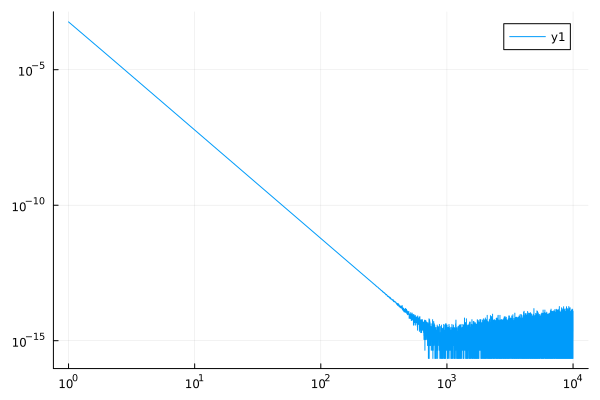

In [8]:
f(x)=exp(x)
t=range(1, 10000, length=10000)
w=[]
for i in 1:10000
  app=simp(f, 0.0, 1.0, i)
  push!(w, abs(app-exp(1)+1))
end
plot(t, w, xscale=:log10, yscale=:log10)

---
# 3. Funzioni di quadratura in Julia


Il pacchetto `QuadGK' in Julia implementa funzioni di quadratura numerica per funzioni scalari di una variabile, con scelta automatica (adattiva) del passo di integrazione, usando le formule di quadratura di Gauss–Kronrod.

La funzione `quadgk` prende in input la funzione integranda `f`, gli estremi dell'intervallo di integrazione `a` e `b` e restituisce in output due valori, il primo e' l'approssimazione dell'intergale, il secondo e' l'errore stimato dell'approssimazione.

Ad esempio, per approssimare $\int_0^\pi \sin(x)e^{-x} dx$, eseguiamo i comandi

```julia
# Definiamo la funzione integranda
g(x) = sin(x) * exp(-x)

# Calcoliamo l'integrale da 0 a π
risultato, errore = quadgk(g, 0, pi)

println("Risultato: ", risultato)
println("Accuratezza: ", errore)



**Esercizio 4**. Consideriamo la curva parametrica nel piano di equazioni
\begin{eqnarray*}
&& x(t)=\int_0^t \cos(u^2)du,\\
&& y(t)=\int_0^t\sin(u^2)du.
\end{eqnarray*}
Si disegni il grafico della curva $(x(t),y(t))$, con $t\in [-4\pi,4\pi]$, calcolando gli integrali con la funzione `quadgk`.

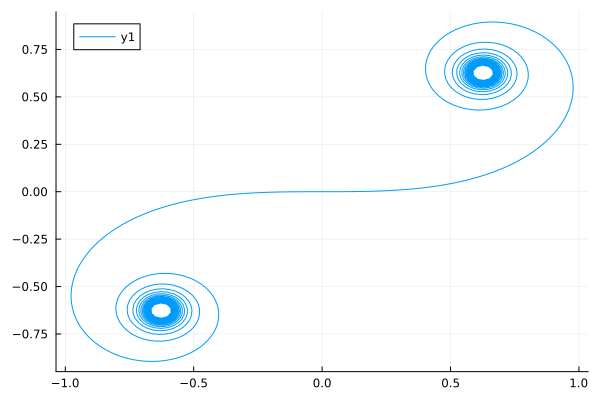

In [11]:
t=range(-12.56, 12.56, length=1000)
f1(x)=cos(x^2)
f2(x)=sin(x^2)
function p1(x)
   a,b = quadgk(f1, 0.0, x)
   return a
end

function p2(x)
  a,b = quadgk(f2, 0.0, x)
  return a
end

cx=p1.(t)
cy=p2.(t)
plot(cx, cy)
